Columns:
 Index(['Age', 'Cholesterol', 'MaxHeartRate', 'RestingBP', 'HeartDisease'], dtype='object')

Target distribution:
 HeartDisease
1    83
0    37
Name: count, dtype: int64

Logistic Regression Accuracy: 0.7916666666666666
Decision Tree Accuracy: 1.0
SVM Accuracy: 0.875
Stacking Accuracy: 1.0


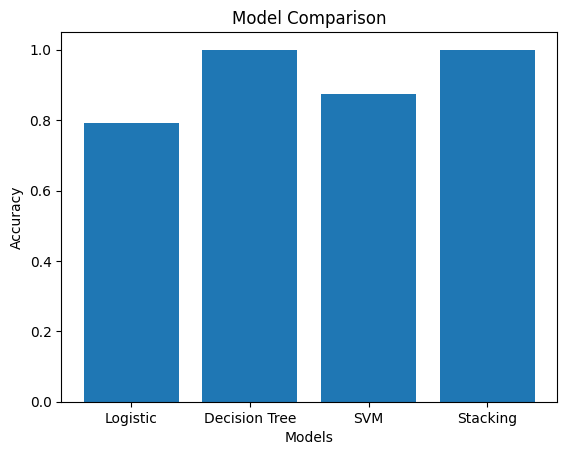

In [2]:
# Name: Navithanjali
# Roll No: 24BAD077
# Scenario 4 - Stacking (FINAL FIX)

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score

# ------------------ Load Dataset ------------------
data = pd.read_csv("heart_stacking.csv")

# Clean column names
data.columns = data.columns.str.strip()

print("Columns:\n", data.columns)

# ✅ CORRECT TARGET COLUMN
target_col = "HeartDisease"

# ------------------ Features & Target ------------------
X = data.drop(target_col, axis=1)
y = data[target_col]

print("\nTarget distribution:\n", y.value_counts())

# ------------------ Train Test Split ------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ------------------ Base Models ------------------
lr = LogisticRegression(max_iter=1000)
dt = DecisionTreeClassifier()
svm = SVC(probability=True)

# Train base models
lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
svm.fit(X_train, y_train)

# Predictions
pred_lr = lr.predict(X_test)
pred_dt = dt.predict(X_test)
pred_svm = svm.predict(X_test)

# ------------------ Stacking ------------------
estimators = [
    ('lr', LogisticRegression(max_iter=1000)),
    ('dt', DecisionTreeClassifier()),
    ('svm', SVC(probability=True))
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

stack.fit(X_train, y_train)
pred_stack = stack.predict(X_test)

# ------------------ Accuracy ------------------
acc_lr = accuracy_score(y_test, pred_lr)
acc_dt = accuracy_score(y_test, pred_dt)
acc_svm = accuracy_score(y_test, pred_svm)
acc_stack = accuracy_score(y_test, pred_stack)

print("\nLogistic Regression Accuracy:", acc_lr)
print("Decision Tree Accuracy:", acc_dt)
print("SVM Accuracy:", acc_svm)
print("Stacking Accuracy:", acc_stack)

# ------------------ Visualization ------------------
models = ["Logistic", "Decision Tree", "SVM", "Stacking"]
accuracies = [acc_lr, acc_dt, acc_svm, acc_stack]

plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()